# PyCCL Tutorial: Cosmology, Distances, and Matter Power Spectra

This notebook introduces [PyCCL](https://ccl.readthedocs.io/) (the Core Cosmology Library), a Python package for computing cosmological quantities with validated numerical accuracy.

## What you will learn

1. How to import `pyccl`, `numpy`, and `matplotlib`
2. How to define a flat $\Lambda$ CDM cosmology object
3. How the scale factor $a$ relates to redshift $z$
4. How to compute a comoving distance
5. Basic NumPy tools for building arrays and grids
6. How to compute and plot linear and non-linear matter power spectra $P(k)$

At the end of the notebook you will find **two assignments**. Task 1 is a warm-up on distance measures; Task 2 is the main exercise on power spectra at several redshifts.

**Useful documentation:** [PyCCL quickstart](https://ccl.readthedocs.io/en/latest/source/quickstart.html) · [API reference](https://ccl.readthedocs.io/en/latest/api/)

## 1. Imports

We will use three libraries throughout this notebook:

| Package | Role |
|---------|------|
| `pyccl` | Cosmology calculations (distances, power spectra, …) |
| `numpy` | Numerical arrays and grids (`linspace`, `logspace`, …) |
| `matplotlib.pyplot` | Plotting figures |

Run the cell below and check that PyCCL prints a version number (e.g. `3.2.1`).

In [1]:
import json
from pathlib import Path

import numpy
import pyccl
from matplotlib import pyplot

In [2]:
path = Path.cwd().parent
code_path = path / 'Code'
data_path = path / 'Data'
figure_path = path / 'Figure'

## 2. Defining a cosmology object

Almost every calculation in PyCCL starts from a `Cosmology` object. This object stores the cosmological parameters and caches derived quantities (distances, power spectra, …) as you request them.

In this notebook we use a **flat $\Lambda$CDM** model with Planck-like parameters:

| Parameter | Meaning |
|-----------|---------|
| `Omega_c` | Cold dark matter density today |
| `Omega_b` | Baryon density today |
| `h` | Hubble parameter $H_0 = 100\,h\,\mathrm{km\,s^{-1}\,Mpc^{-1}}$ |
| `sigma8` | RMS matter fluctuation amplitude in spheres of $8\,h^{-1}\mathrm{Mpc}$ |
| `n_s` | Spectral index of the primordial power spectrum |
| `transfer_function='boltzmann_camb'` | Use CAMB to compute the matter transfer function |

We will reuse the same `cosmology` object in all later cells.

In [3]:
# Flat LCDM cosmology (Planck-like parameters)
cosmology = pyccl.Cosmology(
    Omega_c=0.27,
    Omega_b=0.045,
    h=0.67,
    sigma8=0.8,
    n_s=0.96,
    transfer_function='boltzmann_camb',
    matter_power_spectrum='camb'
)

print(cosmology)

<pyccl.cosmology.Cosmology>
	Neff    = 3.044
	Omega_b = 0.045
	Omega_c = 0.27
	h       = 0.67
	n_s     = 0.96
	sigma8  = 0.8
	matter_power_spectrum = camb
	extra_parameters =
	HASH_ACCURACY_PARAMS = 0xffadca81c23d1315


## 3. Scale factor and redshift

In cosmology, the **scale factor** $a$ describes the relative size of the Universe. By convention, $a = 1$ today.

The cosmological **redshift** $z$ is related to the scale factor by

$$
a = \frac{1}{1 + z}.
$$

Examples:
- Today: $z = 0$ $\Rightarrow$ $a = 1$
- At $z = 1$: $a = 0.5$
- At $z = 2$: $a = 1/3$

**Important for PyCCL:** many functions take the scale factor `a` as an argument, not redshift. Whenever you are given a redshift, convert it with `a = 1.0 / (1.0 + z)` before calling CCL.

## 4. A first distance calculation

As a sanity check, we compute the **comoving radial distance** to $z = 0$ (i.e. to today). The result must be zero, because we are "looking" at our own location.

The function we use is `pyccl.comoving_radial_distance(cosmo, a)`. Later, in **Task 1**, you will compute several related distance measures over a range of redshifts and plot them.

In [4]:
# Quick sanity check: comoving distance at z = 0

z0 = 0.0
a0 = 1.0 / (1.0 + z0)
chi0 = pyccl.comoving_radial_distance(cosmology, a0)
print("Comoving distance to z={}: {:.2f}Mpc".format(z0, chi0))

Comoving distance to z=0.0: 0.00Mpc


## 5. NumPy essentials for this notebook

Before computing power spectra, we briefly recap a few NumPy tools. In scientific Python we almost always work with **arrays**, not plain Python lists, because:

- arrays support element-wise arithmetic
- they are faster for large grids
- libraries like PyCCL and Matplotlib expect array-like inputs

The next cells show:
1. converting a list to an array
2. basic statistics (`.mean()`, `.std()`, `.min()`, `.max()`)
3. building evenly spaced grids with `numpy.arange` and `numpy.linspace`
4. building a **logarithmic** $k$-grid with `numpy.logspace` (standard for power spectra)

In [5]:
value_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
value_array = numpy.array(value_list)
print(value_list, value_array)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] [ 0  1  2  3  4  5  6  7  8  9 10]


In [6]:
value_array.mean(), value_array.std(), value_array.min(), value_array.max()

(np.float64(5.0), np.float64(3.1622776601683795), np.int64(0), np.int64(10))

### Building regular grids

- `numpy.arange(start, stop, step)` — values from `start` up to (but not including) `stop`, with a fixed step
- `numpy.linspace(start, stop, num)` — `num` points equally spaced between `start` and `stop` (inclusive if `endpoint=True`)

You will use something like `linspace` in Task 1 to build a redshift array.

In [7]:
array = numpy.arange(start=0, stop=10, step=1)
print(array)
grid = numpy.linspace(start=0, stop=10, num=11, endpoint=True)
print(grid)

[0 1 2 3 4 5 6 7 8 9]
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


### A logarithmic $k$-grid for power spectra

The matter power spectrum $P(k)$ is usually plotted over many orders of magnitude in wavenumber $k$. A logarithmic grid is therefore natural:

```python
k_grid = numpy.logspace(start=-4, stop=+2, num=100, endpoint=True)
```

This creates 100 points from $10^{-4}$ to $10^{2}\,\mathrm{Mpc}^{-1}$. We reuse this grid below (and you should reuse it again in Task 2).

In [8]:
k_grid = numpy.logspace(start=-4, stop=+2, num=100, endpoint=True)
print(k_grid)

[1.00000000e-04 1.14975700e-04 1.32194115e-04 1.51991108e-04
 1.74752840e-04 2.00923300e-04 2.31012970e-04 2.65608778e-04
 3.05385551e-04 3.51119173e-04 4.03701726e-04 4.64158883e-04
 5.33669923e-04 6.13590727e-04 7.05480231e-04 8.11130831e-04
 9.32603347e-04 1.07226722e-03 1.23284674e-03 1.41747416e-03
 1.62975083e-03 1.87381742e-03 2.15443469e-03 2.47707636e-03
 2.84803587e-03 3.27454916e-03 3.76493581e-03 4.32876128e-03
 4.97702356e-03 5.72236766e-03 6.57933225e-03 7.56463328e-03
 8.69749003e-03 1.00000000e-02 1.14975700e-02 1.32194115e-02
 1.51991108e-02 1.74752840e-02 2.00923300e-02 2.31012970e-02
 2.65608778e-02 3.05385551e-02 3.51119173e-02 4.03701726e-02
 4.64158883e-02 5.33669923e-02 6.13590727e-02 7.05480231e-02
 8.11130831e-02 9.32603347e-02 1.07226722e-01 1.23284674e-01
 1.41747416e-01 1.62975083e-01 1.87381742e-01 2.15443469e-01
 2.47707636e-01 2.84803587e-01 3.27454916e-01 3.76493581e-01
 4.32876128e-01 4.97702356e-01 5.72236766e-01 6.57933225e-01
 7.56463328e-01 8.697490

## 6. Linear and non-linear matter power spectra at $z = 0$

The **matter power spectrum** $P(k)$ describes how strongly matter density fluctuates on different spatial scales (wavenumber $k$).

- **Linear** $P(k)$: valid when density fluctuations are small. On large scales (small $k$), structure growth remains approximately linear.
- **Non-linear** $P(k)$: includes the effects of gravitational collapse on small scales (large $k$). At high $k$, the non-linear spectrum is enhanced relative to the linear one.

In PyCCL we use:

- `pyccl.power.linear_power(cosmo, k, a, ...)`
- `pyccl.power.nonlin_power(cosmo, k, a, ...)`

Here we evaluate both at redshift $z = 0$ (scale factor `a0 = 1`), using the same `k_grid` defined above. The argument `p_of_k_a='delta_matter:delta_matter'` asks for the matter–matter power spectrum.

The worked example below plots **linear as a solid line** and **non-linear as a dashed line**. In Task 2 you will extend this idea to several redshifts and several colours.

In [9]:
power_linear = pyccl.power.linear_power(
    cosmo=cosmology, 
    k=k_grid, 
    a=a0, 
    p_of_k_a='delta_matter:delta_matter'
)
print(power_linear)

[1.92940339e+03 2.20560954e+03 2.52121579e+03 2.88177580e+03
 3.29358558e+03 3.76378304e+03 4.30042759e+03 4.91258456e+03
 5.61044371e+03 6.40534365e+03 7.30991783e+03 8.33808281e+03
 9.50510094e+03 1.08275633e+04 1.23231658e+04 1.40107256e+04
 1.59094047e+04 1.80385533e+04 2.04166742e+04 2.30602957e+04
 2.59831433e+04 2.91934421e+04 3.26931260e+04 3.64739194e+04
 4.05153773e+04 4.47816830e+04 4.92173861e+04 5.37441292e+04
 5.82567034e+04 6.26193207e+04 6.66627369e+04 7.01829011e+04
 7.29430810e+04 7.46825800e+04 7.51366004e+04 7.40725911e+04
 7.13478712e+04 6.69862153e+04 6.12582488e+04 5.47278996e+04
 4.81482654e+04 4.23545178e+04 3.78594425e+04 3.43315189e+04
 3.07873999e+04 2.60264668e+04 2.05541298e+04 1.63093929e+04
 1.40346935e+04 1.16962874e+04 8.72921646e+03 7.11623378e+03
 5.58775865e+03 4.27180700e+03 3.30403095e+03 2.53342543e+03
 1.90250000e+03 1.43157343e+03 1.07043281e+03 7.95064598e+02
 5.87079952e+02 4.31180919e+02 3.15080168e+02 2.29196063e+02
 1.66004716e+02 1.197507

In [10]:
power_non_linear = pyccl.power.nonlin_power(
    cosmo=cosmology, 
    k=k_grid, 
    a=a0, 
    p_of_k_a='delta_matter:delta_matter'
)
print(power_non_linear)

[1.92940737e+03 2.20561453e+03 2.52122196e+03 2.88178333e+03
 3.29359458e+03 3.76379351e+03 4.30043929e+03 4.91259680e+03
 5.61045504e+03 6.40535128e+03 7.30991694e+03 8.33806508e+03
 9.50505263e+03 1.08274623e+04 1.23229765e+04 1.40103930e+04
 1.59088421e+04 1.80376288e+04 2.04151859e+04 2.30579374e+04
 2.59794602e+04 2.91877518e+04 3.26844369e+04 3.64607725e+04
 4.04956727e+04 4.47524515e+04 4.91744646e+04 5.36817970e+04
 5.81672728e+04 6.24927464e+04 6.64863629e+04 6.99415515e+04
 7.26198070e+04 7.42604602e+04 7.46019615e+04 7.34197079e+04
 7.05844392e+04 6.61376963e+04 6.03680687e+04 5.38507831e+04
 4.73384206e+04 4.16519224e+04 3.72869547e+04 3.39122853e+04
 3.05637722e+04 2.60662102e+04 2.08996635e+04 1.69343560e+04
 1.48796222e+04 1.27409334e+04 9.95185444e+03 8.44322805e+03
 6.97770952e+03 5.69124058e+03 4.73075796e+03 3.95373748e+03
 3.30634464e+03 2.81021429e+03 2.41469338e+03 2.09523925e+03
 1.83286334e+03 1.61192077e+03 1.42010117e+03 1.24858404e+03
 1.09136945e+03 9.452683

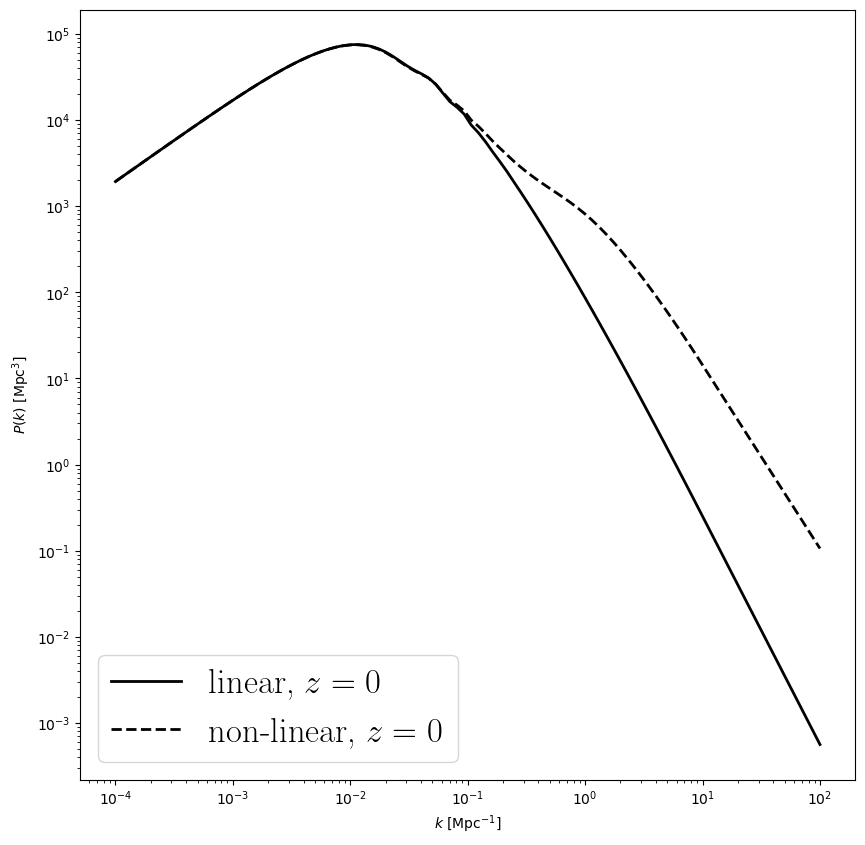

In [11]:
figure, plot = pyplot.subplots(nrows=1, ncols=1, figsize=(10, 10))
pyplot.rcParams['font.family'] = 'Times New Roman'
pyplot.rcParams['text.usetex'] = True
pyplot.rcParams['font.size'] = 25

plot.plot(
    k_grid, power_linear,
    linewidth=2, linestyle='-', color='black',
    label=r'linear, $z=0$'
)

plot.plot(
    k_grid, power_non_linear,
    linewidth=2, linestyle='--', color='black',
    label=r'non-linear, $z=0$'
)

plot.set_xscale('log')
plot.set_yscale('log')
plot.set_xlabel(r'$k$ [Mpc$^{-1}$]')
plot.set_ylabel(r'$P(k)$ [Mpc$^3$]')
plot.legend()
pyplot.show()

---

# Assignments

Complete the two tasks below in **new code cells** that you add after each task description. Do **not** overwrite the worked examples above — build on them.

---

## Task 1 (warm-up): Cosmological distances vs redshift

Plot the following distance measures as a function of redshift between $z = 0$ and $z = 10$:

1. **Comoving radial distance**
2. **Comoving transverse distance**
3. **Luminosity distance**
4. **Angular diameter distance**

### Suggested steps

1. Build a redshift array, for example with `numpy.linspace(0, 10, ...)`.
2. Convert redshifts to scale factors: `a = 1.0 / (1.0 + z)`.
3. Search the [PyCCL documentation](https://ccl.readthedocs.io/) for the distance functions that take `(cosmo, a)` as arguments. Useful keywords to search for: `comoving_radial_distance`, `comoving_transverse_distance`, `luminosity_distance`, `angular_diameter_distance`.
4. Evaluate each function on your scale-factor array (using the same `cosmology` object defined above).
5. Make **one figure** with all four curves vs $z$. Add axis labels and a legend.

### Hints

- Start from the $z = 0$ sanity-check cell and generalise it to an *array* of redshifts.
- In a flat Universe, the comoving radial and comoving transverse distances are equal — your plot should reflect that.
- At high redshift you should see $D_L > D_M > D_A$.

**Add your solution cell(s) immediately below this markdown cell.**

*← Student workspace for Task 1: add code cells here.*

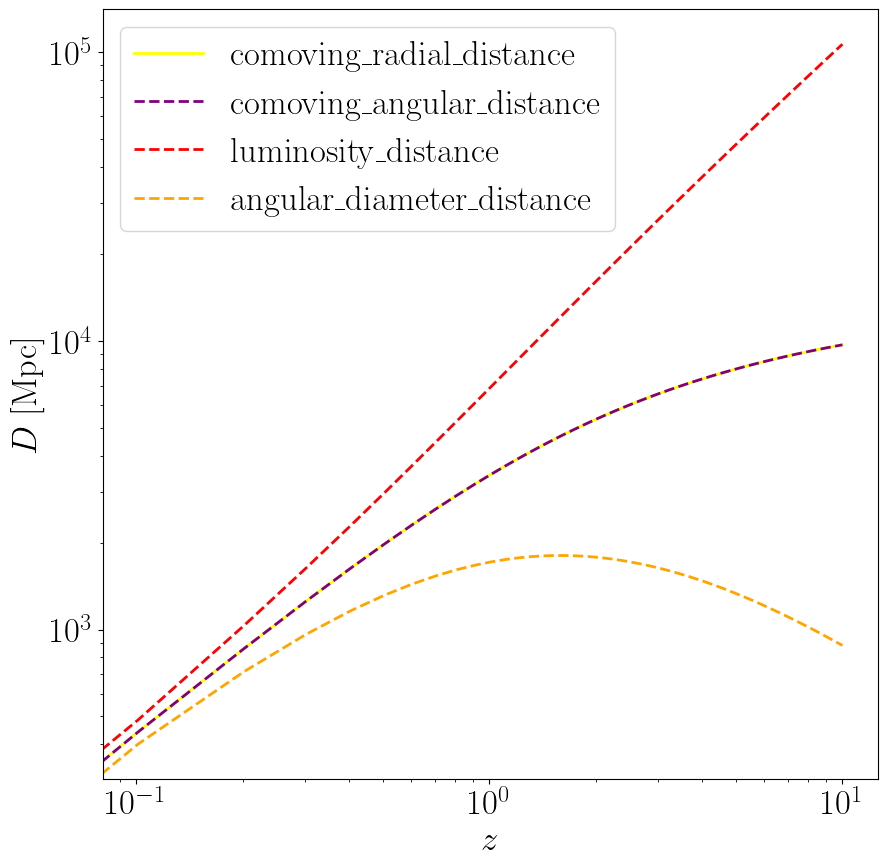

In [12]:
z = numpy.linspace(start=0, stop=10, num=100, endpoint=True)
a = (1.0 / (1.0 + z))

comoving_radial_distance = pyccl.background.comoving_radial_distance(cosmology, a)
comoving_angular_distance = pyccl.background.comoving_angular_distance(cosmology, a)
luminosity_distance = pyccl.background.luminosity_distance(cosmology, a)
angular_diameter_distance = pyccl.background.angular_diameter_distance(cosmology, a)

figure, plot = pyplot.subplots(nrows=1, ncols=1, figsize=(10, 10))
pyplot.rcParams['font.family'] = 'Times New Roman'
pyplot.rcParams['text.usetex'] = True
pyplot.rcParams['font.size'] = 25

plot.plot(
    z, comoving_radial_distance,
    linewidth=2, linestyle='-', color='yellow',
    label='comoving_radial_distance'
)

plot.plot(
    z, comoving_angular_distance,
    linewidth=2, linestyle='--', color='purple',
    label='comoving_angular_distance'
)

plot.plot(
    z, luminosity_distance,
    linewidth=2, linestyle='--', color='red',
    label='luminosity_distance'
)

plot.plot(
    z, angular_diameter_distance,
    linewidth=2, linestyle='--', color='orange',
    label='angular_diameter_distance'
)

plot.set_xscale('log')
plot.set_yscale('log')
plot.set_xlabel(r'$z$')
plot.set_ylabel(r'$D$ [Mpc]')
plot.legend()
pyplot.show()



---

## Task 2 (main): Matter power spectra at $z = 0$, $1$, and $2$

Extend the $z = 0$ power-spectrum example and compute **linear** and **non-linear** matter power spectra at **redshift $z = 1$ and $z = 2$** as well. Then plot **all six curves on a single figure**, together with the $z = 0$ results.

### Plotting requirements

| Style | Meaning |
|-------|---------|
| **Solid line** (`linestyle='-'`) | Linear $P(k)$ |
| **Dashed line** (`linestyle='--'`) | Non-linear $P(k)$ |
| **Different colours** | Different redshifts ($z = 0$, $1$, $2$) |

Also include:
- logarithmic axes for both $k$ and $P(k)$
- axis labels
- a clear legend

### Suggested steps

1. Reuse the existing `k_grid` (or recreate an identical one with `numpy.logspace`).
2. For each redshift $z \in \{0, 1, 2\}$, compute the scale factor `a = 1.0 / (1.0 + z)`.
3. Call `pyccl.power.linear_power(...)` and `pyccl.power.nonlin_power(...)` at each scale factor, exactly as in the worked example. Store the results in new arrays (e.g. `power_linear_z1`, `power_non_linear_z1`, …).
4. Create one `pyplot.subplots` figure and call `plot.plot(...)` six times (or loop over redshifts).
5. Choose three colours (one per redshift). Keep solid vs dashed to distinguish linear vs non-linear.

### Hints

- You do **not** need new CCL functions — the same `linear_power` / `nonlin_power` calls work at any redshift once `a` is set correctly.
- You may keep the $z = 0$ arrays already computed above and only add $z = 1$ and $z = 2$, then plot everything together.
- On large scales (small $k$), linear and non-linear curves should nearly overlap; the difference grows toward small scales (large $k$).
- At higher redshift, the overall amplitude of $P(k)$ is lower because structure has had less time to grow.

**Add your solution cell(s) immediately below this markdown cell.**

*← Student workspace for Task 2: add code cells here.*

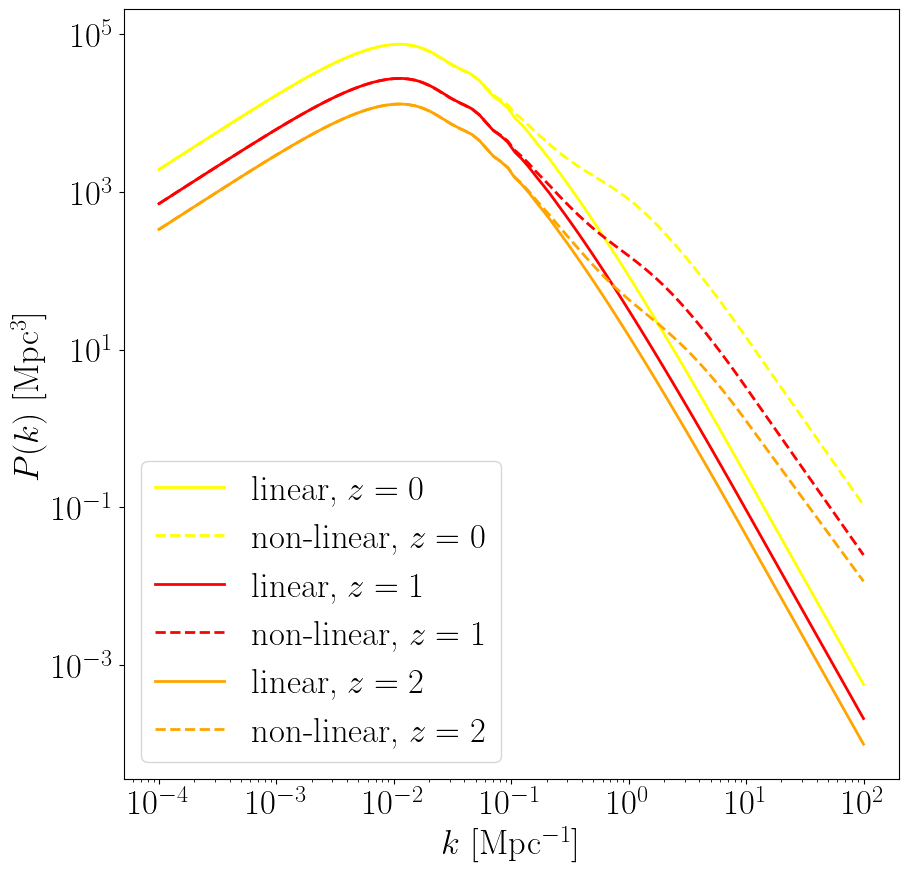

In [13]:
k_grid = numpy.logspace(start=-4, stop=+2, num=100, endpoint=True)

z_list = [0, 1, 2]
color_list = ['yellow', 'red', 'orange']

figure, plot = pyplot.subplots(nrows=1, ncols=1, figsize=(10, 10))
pyplot.rcParams['font.family'] = 'Times New Roman'
pyplot.rcParams['text.usetex'] = True
pyplot.rcParams['font.size'] = 25

for z, color in zip(z_list, color_list):
    a = (1.0 / (1.0 + z)) 
    power_linear = pyccl.power.linear_power(
        cosmo=cosmology, 
        k=k_grid, 
        a=a, 
        p_of_k_a='delta_matter:delta_matter'
    )
    power_non_linear = pyccl.power.nonlin_power(
        cosmo=cosmology, 
        k=k_grid, 
        a=a, 
        p_of_k_a='delta_matter:delta_matter'
    )
    
    plot.plot(
        k_grid, power_linear,
        linewidth=2, linestyle='-', color=color,
        label=f'linear, $z={z}$'
    )
    
    plot.plot(
        k_grid, power_non_linear,
        linewidth=2, linestyle='--', color=color,
        label=f'non-linear, $z={z}$'
    )

plot.set_xscale('log')
plot.set_yscale('log')
plot.set_xlabel(r'$k$ [Mpc$^{-1}$]')
plot.set_ylabel(r'$P(k)$ [Mpc$^3$]')
plot.legend()

pyplot.show()
